## 🎯 Hipóteses para o EDA — Telco Churn

**1. Perfil Demográfico**

- H1: Clientes mais velhos (Senior Citizens) têm maior taxa de churn do que clientes jovens.
- H2: Clientes sem dependentes têm maior propensão ao churn — menor "custo de troca".
- H3: Clientes casados apresentam menor churn, por maior estabilidade financeira e de hábitos.

**2. Relacionamento com a Empresa**

- H4: Quanto maior o tempo de contrato (Tenure), menor a taxa de churn — fidelidade cresce com o tempo.
- H5: Clientes que indicaram amigos (Referred a Friend) têm menor churn, pois possuem vínculo maior com a marca.
- H6: Clientes que receberam ofertas específicas (Offer C, D, E) têm churn diferente de quem não recebeu oferta alguma.

**3. Tipo de Contrato e Pagamento**

- H7: Clientes com contrato mensal (Month-to-Month) têm churn significativamente maior do que contratos anuais ou bianuais.
- H8: O método de pagamento influencia o churn — pagamentos automáticos (cartão/débito) estão associados a menor evasão.
- H9: Clientes com fatura digital (Paperless Billing) têm maior churn — perfil mais digital e mais propenso a comparar concorrentes.

**4. Serviços Contratados**

- H10: Clientes de internet Fiber Optic têm maior churn do que clientes de DSL — possivelmente por preço mais alto ou maior concorrência nesse segmento.
- H11: Clientes sem serviços adicionais (segurança online, backup, suporte técnico) têm maior churn — menor engajamento com o ecossistema.
- H12: Clientes com mais serviços de streaming contratados tendem a permanecer mais — maior dependência da operadora.

**5. Financeiro**

- H13: Clientes com mensalidade mais alta (Monthly Charge) têm maior probabilidade de churn — sensibilidade a preço.
- H14: Clientes com alto CLTV (Customer Lifetime Value) têm menor churn — representam o segmento mais valioso e satisfeito.
- H15: Clientes com reembolsos (Total Refunds) têm maior churn — sinal de insatisfação anterior.

**6. Satisfação e Motivo de Churn**

- H16: O Satisfaction Score é o preditor mais forte de churn — scores baixos concentram a maior parte dos churners.
- H17: O principal motivo de churn é relacionado a concorrentes (melhor oferta/preço), não à insatisfação com o serviço em si.
- H18: Clientes que saem por "Atitude" ou "Dissatisfação" têm tenure menor do que os que saem por "Competidor" — sugerindo problemas precoces na jornada.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
sns.set_style("white")  # remove o grid
warnings.filterwarnings('ignore')

In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
df = pd.read_csv('~/Projeto/Portfolio/Portfolio2/Churn/data/telco.csv')
df




,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,Female,30,No,No,No,No,0,United States,California,...,0,1639.44,3039.53,5,Stayed,No,45,5306,NaN,NaN
7039,6840-RESVB,Male,38,No,No,Yes,Yes,2,United States,California,...,0,865.20,2807.47,3,Stayed,No,59,2140,NaN,NaN
7040,2234-XADUH,Female,30,No,No,Yes,Yes,2,United States,California,...,0,2135.52,9453.04,4,Stayed,No,71,5560,NaN,NaN
7041,4801-JZAZL,Female,32,No,No,Yes,Yes,2,United States,California,...,0,0.00,319.21,4,Stayed,No,59,2793,NaN,NaN


In [3]:
CHURN_COLOR   = '#E74C3C'   # red  – churned
RETAIN_COLOR  = '#2ECC71'   # green – retained
NEUTRAL_COLOR = '#3498DB'   # blue  – neutral
BG_COLOR      = '#F8F9FA'
GRID_COLOR    = '#E0E0E0'

plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.facecolor'   : BG_COLOR,
    'figure.facecolor' : 'white',
    'axes.grid'        : True,
    'grid.color'       : GRID_COLOR,
    'grid.linewidth'   : 0.7,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.labelsize'   : 11,
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'xtick.labelsize'  : 10,
    'ytick.labelsize'  : 10,
})

# Helper – churn rate per category
def churn_rate(data, col):
    return data.groupby(col)['Churn Label'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index(name='Churn Rate (%)')

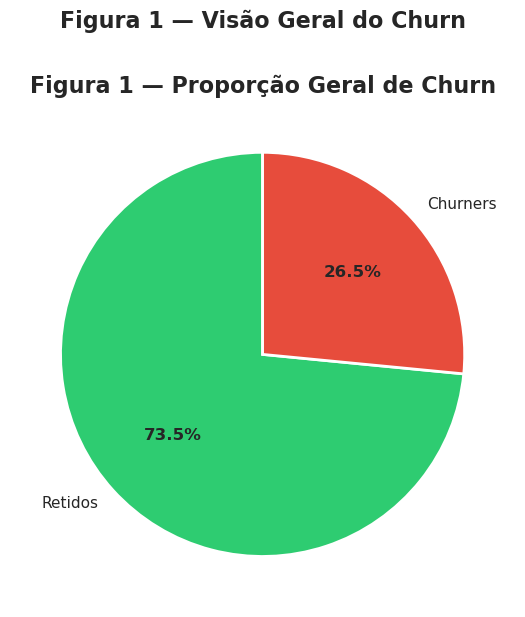

In [4]:
fig = plt.figure(figsize=(6,6))
fig.suptitle('Figura 1 — Visão Geral do Churn', fontsize=16, fontweight='bold', y=1.02)

plt.title('Figura 1 — Proporção Geral de Churn', fontsize=16, fontweight='bold')

counts = df['Churn Label'].value_counts()
colors_pie = [RETAIN_COLOR, CHURN_COLOR]

wedges, texts, autotexts = plt.pie(
    counts,
    labels=['Retidos', 'Churners'],
    autopct='%1.1f%%',
    colors=colors_pie,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)

for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')

plt.tight_layout()
plt.show()

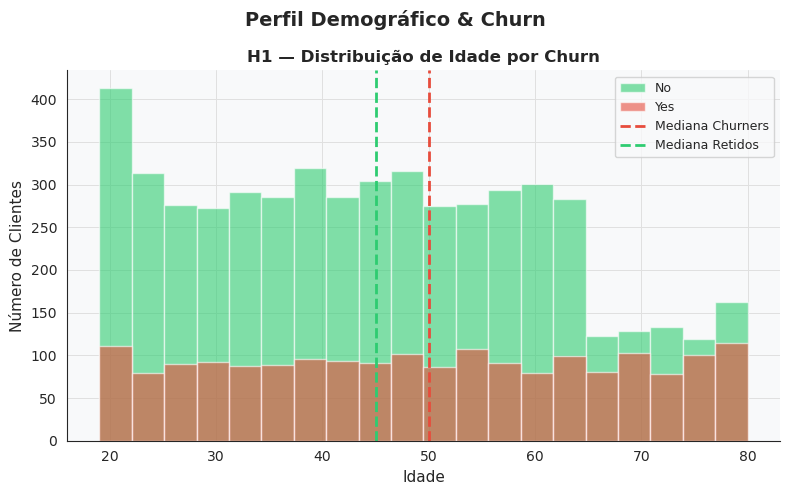

In [5]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Perfil Demográfico & Churn', fontsize=14, fontweight='bold')
plt.title('H1 — Distribuição de Idade por Churn', fontsize=12)

for label, color in [('No', RETAIN_COLOR), ('Yes', CHURN_COLOR)]:
    subset = df[df['Churn Label'] == label]['Age']
    plt.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='white')

plt.axvline(df[df['Churn Label']=='Yes']['Age'].median(),
            color=CHURN_COLOR, linestyle='--', linewidth=2, label='Mediana Churners')

plt.axvline(df[df['Churn Label']=='No']['Age'].median(),
            color=RETAIN_COLOR, linestyle='--', linewidth=2, label='Mediana Retidos')

plt.xlabel('Idade')
plt.ylabel('Número de Clientes')
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

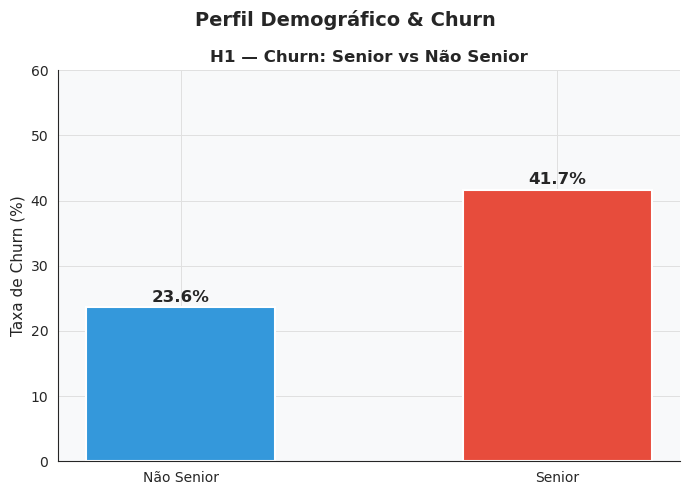

In [6]:
fig = plt.figure(figsize=(7,5))

plt.suptitle('Perfil Demográfico & Churn', fontsize=14, fontweight='bold')
plt.title('H1 — Churn: Senior vs Não Senior', fontsize=12)

cr_sc = churn_rate(df, 'Senior Citizen')
cr_sc['Label'] = cr_sc['Senior Citizen'].map({'Yes': 'Senior', 'No': 'Não Senior'})

colors_sc = [NEUTRAL_COLOR, CHURN_COLOR]

bars = plt.bar(
    cr_sc['Label'],
    cr_sc['Churn Rate (%)'],
    color=colors_sc,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,60)

for bar, val in zip(bars, cr_sc['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

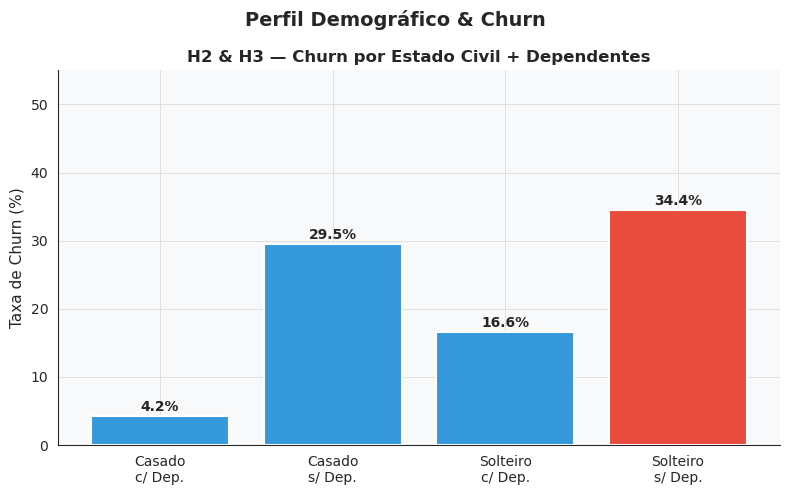

In [7]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Perfil Demográfico & Churn', fontsize=14, fontweight='bold')
plt.title('H2 & H3 — Churn por Estado Civil + Dependentes', fontsize=12)

groups = {
    'Casado\nc/ Dep.': df[(df['Married']=='Yes') & (df['Dependents']=='Yes')]['Churn Label'],
    'Casado\ns/ Dep.': df[(df['Married']=='Yes') & (df['Dependents']=='No')]['Churn Label'],
    'Solteiro\nc/ Dep.': df[(df['Married']=='No') & (df['Dependents']=='Yes')]['Churn Label'],
    'Solteiro\ns/ Dep.': df[(df['Married']=='No') & (df['Dependents']=='No')]['Churn Label'],
}

labels_g = list(groups.keys())
rates_g  = [(v == 'Yes').mean() * 100 for v in groups.values()]

colors_g = [CHURN_COLOR if r > 30 else NEUTRAL_COLOR for r in rates_g]

bars = plt.bar(
    labels_g,
    rates_g,
    color=colors_g,
    edgecolor='white',
    linewidth=1.5
)

plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,55)

for bar, val in zip(bars, rates_g):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

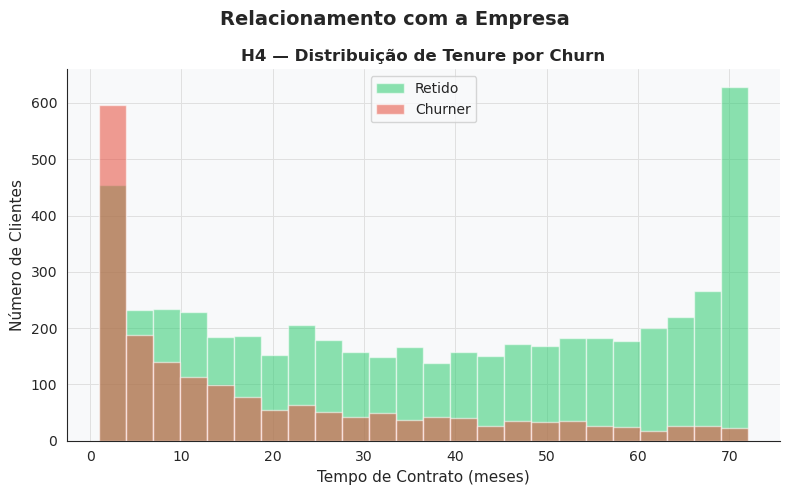

In [8]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Relacionamento com a Empresa', fontsize=14, fontweight='bold')
plt.title('H4 — Distribuição de Tenure por Churn', fontsize=12)

for label, color in [('No', RETAIN_COLOR), ('Yes', CHURN_COLOR)]:
    subset = df[df['Churn Label'] == label]['Tenure in Months']
    
    plt.hist(
        subset,
        bins=24,
        alpha=0.55,
        color=color,
        label=f'{"Retido" if label=="No" else "Churner"}',
        edgecolor='white'
    )

plt.xlabel('Tempo de Contrato (meses)')
plt.ylabel('Número de Clientes')
plt.legend()

plt.tight_layout()
plt.show()

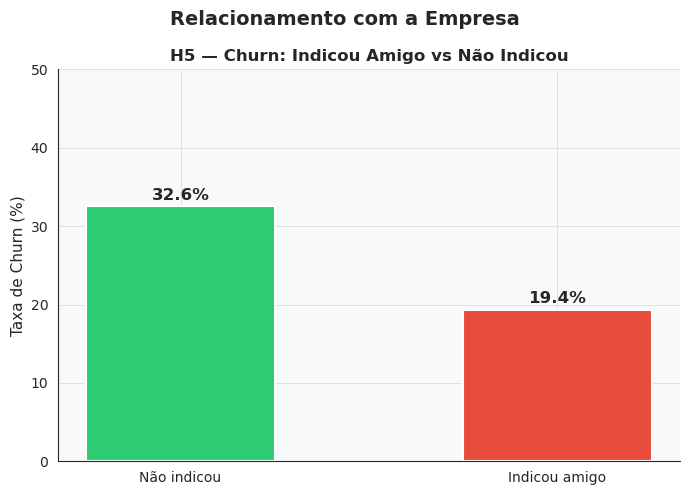

In [9]:
fig = plt.figure(figsize=(7,5))

plt.suptitle('Relacionamento com a Empresa', fontsize=14, fontweight='bold')
plt.title('H5 — Churn: Indicou Amigo vs Não Indicou', fontsize=12)

cr_ref = churn_rate(df, 'Referred a Friend')
cr_ref['Label'] = cr_ref['Referred a Friend'].map({
    'Yes': 'Indicou amigo',
    'No': 'Não indicou'
})

bars = plt.bar(
    cr_ref['Label'],
    cr_ref['Churn Rate (%)'],
    color=[RETAIN_COLOR, CHURN_COLOR],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,50)

for bar, val in zip(bars, cr_ref['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

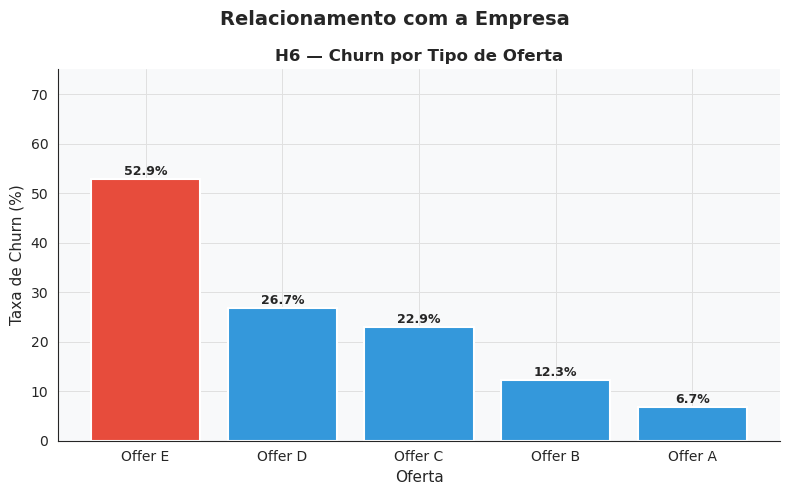

In [10]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Relacionamento com a Empresa', fontsize=14, fontweight='bold')
plt.title('H6 — Churn por Tipo de Oferta', fontsize=12)

cr_offer = churn_rate(df, 'Offer')
cr_offer = cr_offer.sort_values('Churn Rate (%)', ascending=False)

colors_offer = [
    CHURN_COLOR if v > 40 else NEUTRAL_COLOR
    for v in cr_offer['Churn Rate (%)']
]

bars = plt.bar(
    cr_offer['Offer'],
    cr_offer['Churn Rate (%)'],
    color=colors_offer,
    edgecolor='white',
    linewidth=1.5
)

plt.xlabel('Oferta')
plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,75)

for bar, val in zip(bars, cr_offer['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

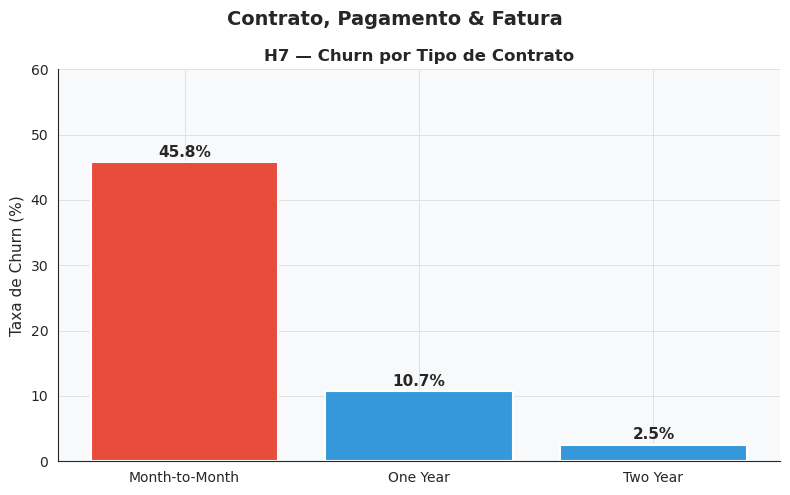

In [11]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Contrato, Pagamento & Fatura', fontsize=14, fontweight='bold')
plt.title('H7 — Churn por Tipo de Contrato', fontsize=12)

cr_contract = churn_rate(df, 'Contract')
cr_contract = cr_contract.sort_values('Churn Rate (%)', ascending=False)

colors_cont = [
    CHURN_COLOR if v > 30 else NEUTRAL_COLOR
    for v in cr_contract['Churn Rate (%)']
]

bars = plt.bar(
    cr_contract['Contract'],
    cr_contract['Churn Rate (%)'],
    color=colors_cont,
    edgecolor='white',
    linewidth=1.5
)

plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,60)

for bar, val in zip(bars, cr_contract['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

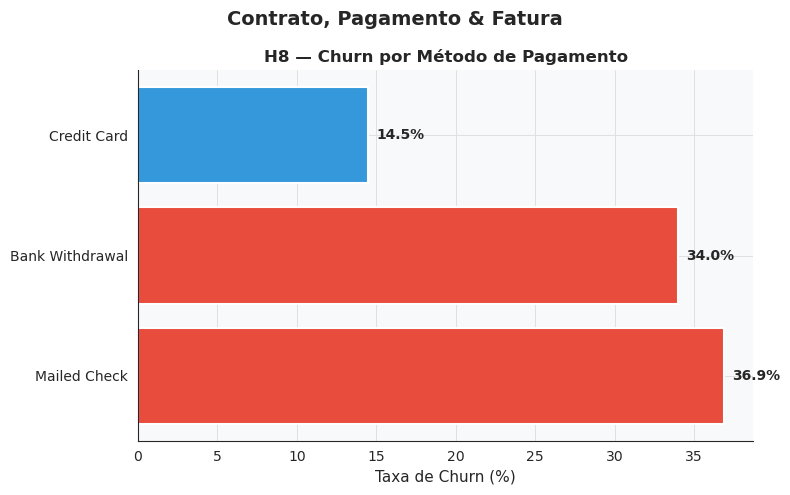

In [12]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Contrato, Pagamento & Fatura', fontsize=14, fontweight='bold')
plt.title('H8 — Churn por Método de Pagamento', fontsize=12)

cr_pay = churn_rate(df, 'Payment Method')
cr_pay = cr_pay.sort_values('Churn Rate (%)', ascending=False)

colors_pay = [
    CHURN_COLOR if v > 30 else NEUTRAL_COLOR
    for v in cr_pay['Churn Rate (%)']
]

bars = plt.barh(
    cr_pay['Payment Method'],
    cr_pay['Churn Rate (%)'],
    color=colors_pay,
    edgecolor='white',
    linewidth=1.5
)

plt.xlabel('Taxa de Churn (%)')

for i, val in enumerate(cr_pay['Churn Rate (%)']):
    plt.text(
        val + 0.5,
        i,
        f'{val:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

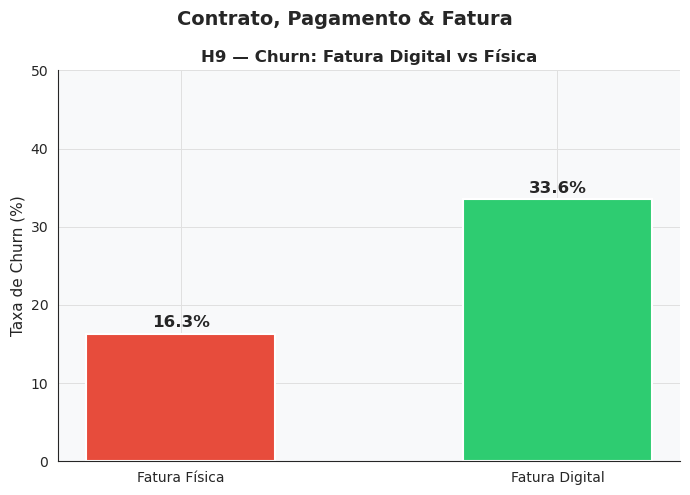

In [13]:
fig = plt.figure(figsize=(7,5))

plt.suptitle('Contrato, Pagamento & Fatura', fontsize=14, fontweight='bold')
plt.title('H9 — Churn: Fatura Digital vs Física', fontsize=12)

cr_pb = churn_rate(df, 'Paperless Billing')

cr_pb['Label'] = cr_pb['Paperless Billing'].map({
    'Yes': 'Fatura Digital',
    'No': 'Fatura Física'
})

bars = plt.bar(
    cr_pb['Label'],
    cr_pb['Churn Rate (%)'],
    color=[CHURN_COLOR, RETAIN_COLOR],
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,50)

for bar, val in zip(bars, cr_pb['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

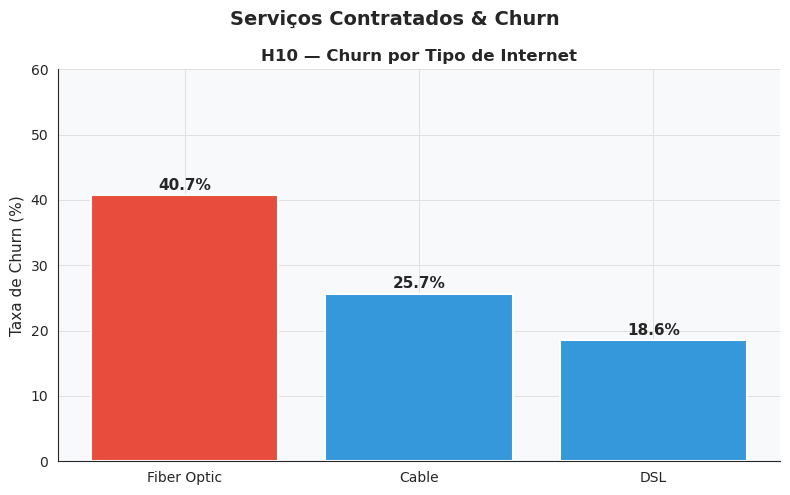

In [14]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Serviços Contratados & Churn', fontsize=14, fontweight='bold')
plt.title('H10 — Churn por Tipo de Internet', fontsize=12)

cr_int = churn_rate(df[df['Internet Service'] == 'Yes'], 'Internet Type')
cr_int = cr_int.sort_values('Churn Rate (%)', ascending=False)

colors_int = [
    CHURN_COLOR if v > 35 else NEUTRAL_COLOR
    for v in cr_int['Churn Rate (%)']
]

bars = plt.bar(
    cr_int['Internet Type'],
    cr_int['Churn Rate (%)'],
    color=colors_int,
    edgecolor='white',
    linewidth=1.5
)

plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,60)

for bar, val in zip(bars, cr_int['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

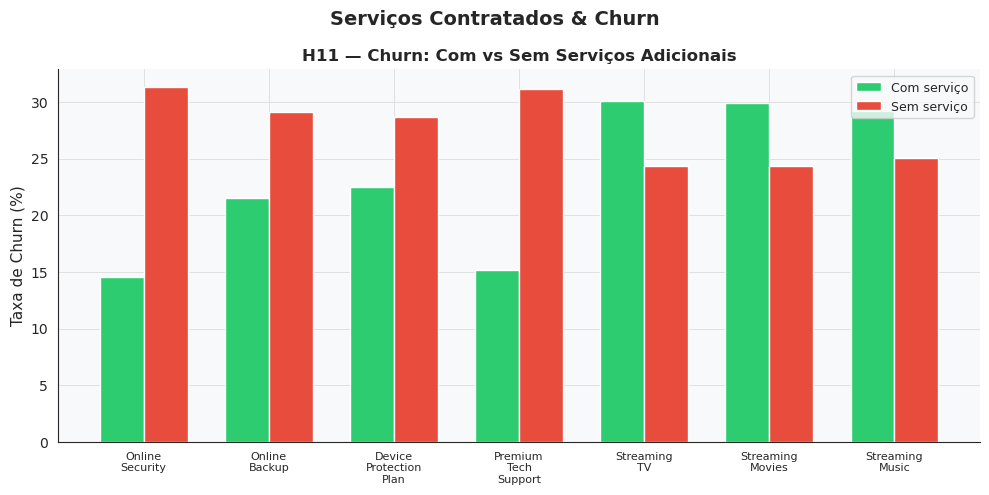

In [15]:
fig = plt.figure(figsize=(10,5))

plt.suptitle('Serviços Contratados & Churn', fontsize=14, fontweight='bold')
plt.title('H11 — Churn: Com vs Sem Serviços Adicionais', fontsize=12)

services = [
    'Online Security',
    'Online Backup',
    'Device Protection Plan',
    'Premium Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Streaming Music'
]

service_rates = []

for s in services:
    has = df[df[s] == 'Yes']['Churn Label'].eq('Yes').mean() * 100
    no  = df[df[s] == 'No']['Churn Label'].eq('Yes').mean() * 100

    service_rates.append({
        'Service': s.replace(' ', '\n'),
        'Com serviço': has,
        'Sem serviço': no
    })

sr_df = pd.DataFrame(service_rates)

x = np.arange(len(sr_df))
w = 0.35

plt.bar(
    x - w/2,
    sr_df['Com serviço'],
    width=w,
    label='Com serviço',
    color=RETAIN_COLOR,
    edgecolor='white'
)

plt.bar(
    x + w/2,
    sr_df['Sem serviço'],
    width=w,
    label='Sem serviço',
    color=CHURN_COLOR,
    edgecolor='white'
)

plt.xticks(x, sr_df['Service'], fontsize=8)
plt.ylabel('Taxa de Churn (%)')
plt.legend(fontsize=9)

plt.tight_layout()
plt.show()

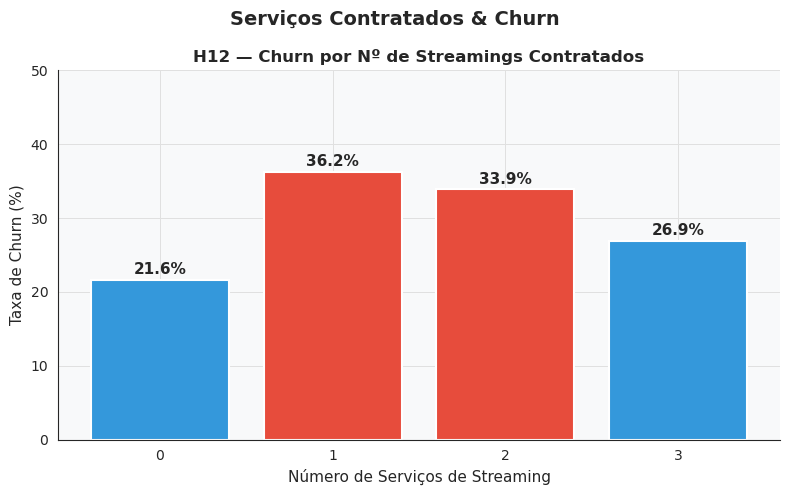

In [16]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Serviços Contratados & Churn', fontsize=14, fontweight='bold')
plt.title('H12 — Churn por Nº de Streamings Contratados', fontsize=12)

streaming_cols = ['Streaming TV', 'Streaming Movies', 'Streaming Music']

df['Num Streaming'] = df[streaming_cols].apply(
    lambda row: (row == 'Yes').sum(),
    axis=1
)

cr_stream = churn_rate(df, 'Num Streaming')

colors_st = [
    CHURN_COLOR if v > 30 else NEUTRAL_COLOR
    for v in cr_stream['Churn Rate (%)']
]

bars = plt.bar(
    cr_stream['Num Streaming'].astype(str),
    cr_stream['Churn Rate (%)'],
    color=colors_st,
    edgecolor='white',
    linewidth=1.5
)

plt.xlabel('Número de Serviços de Streaming')
plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,50)

for bar, val in zip(bars, cr_stream['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

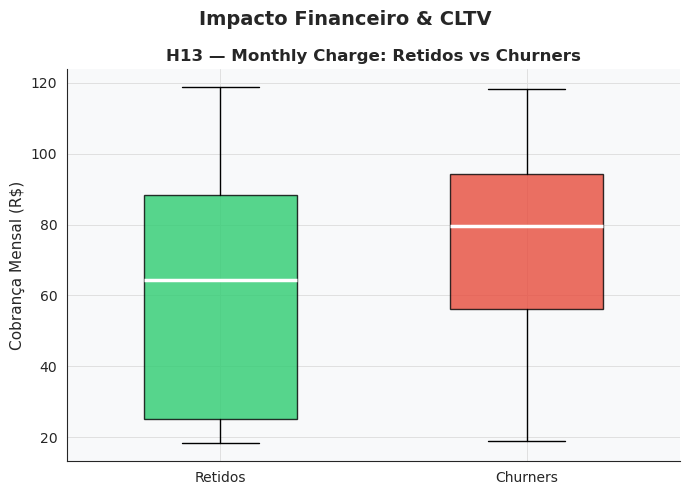

In [17]:
fig = plt.figure(figsize=(7,5))

plt.suptitle('Impacto Financeiro & CLTV', fontsize=14, fontweight='bold')
plt.title('H13 — Monthly Charge: Retidos vs Churners', fontsize=12)

data_box = [
    df[df['Churn Label']=='No']['Monthly Charge'],
    df[df['Churn Label']=='Yes']['Monthly Charge']
]

bp = plt.boxplot(
    data_box,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2.5)
)

for patch, color in zip(bp['boxes'], [RETAIN_COLOR, CHURN_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

plt.xticks([1,2], ['Retidos', 'Churners'])
plt.ylabel('Cobrança Mensal (R$)')

plt.tight_layout()
plt.show()

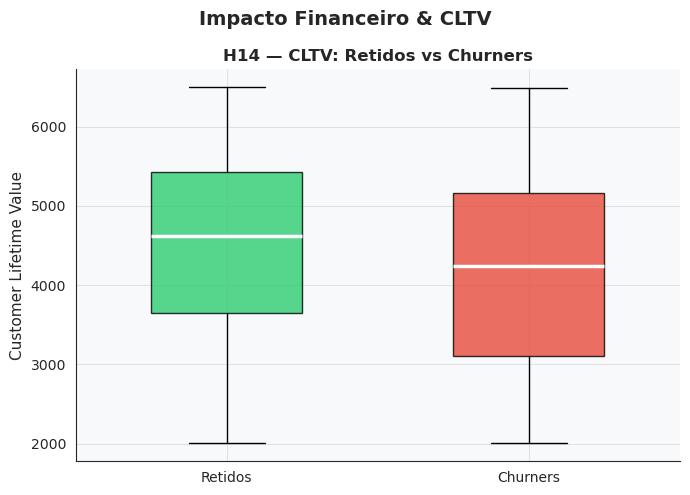

In [18]:
fig = plt.figure(figsize=(7,5))

plt.suptitle('Impacto Financeiro & CLTV', fontsize=14, fontweight='bold')
plt.title('H14 — CLTV: Retidos vs Churners', fontsize=12)

data_cltv = [
    df[df['Churn Label']=='No']['CLTV'],
    df[df['Churn Label']=='Yes']['CLTV']
]

bp = plt.boxplot(
    data_cltv,
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color='white', linewidth=2.5)
)

for patch, color in zip(bp['boxes'], [RETAIN_COLOR, CHURN_COLOR]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

plt.xticks([1,2], ['Retidos', 'Churners'])
plt.ylabel('Customer Lifetime Value')

plt.tight_layout()
plt.show()

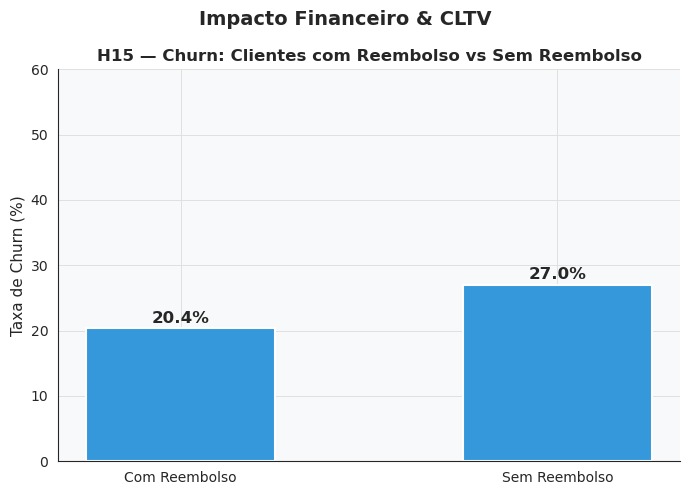

In [19]:
fig = plt.figure(figsize=(7,5))

plt.suptitle('Impacto Financeiro & CLTV', fontsize=14, fontweight='bold')
plt.title('H15 — Churn: Clientes com Reembolso vs Sem Reembolso', fontsize=12)

# Criar variável binária de reembolso
df['Has Refund'] = np.where(df['Total Refunds'] > 0, 'Com Reembolso', 'Sem Reembolso')

cr_refund = churn_rate(df, 'Has Refund')

colors_ref = [
    CHURN_COLOR if v > 30 else NEUTRAL_COLOR
    for v in cr_refund['Churn Rate (%)']
]

bars = plt.bar(
    cr_refund['Has Refund'],
    cr_refund['Churn Rate (%)'],
    color=colors_ref,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

plt.ylabel('Taxa de Churn (%)')
plt.ylim(0,60)

for bar, val in zip(bars, cr_refund['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

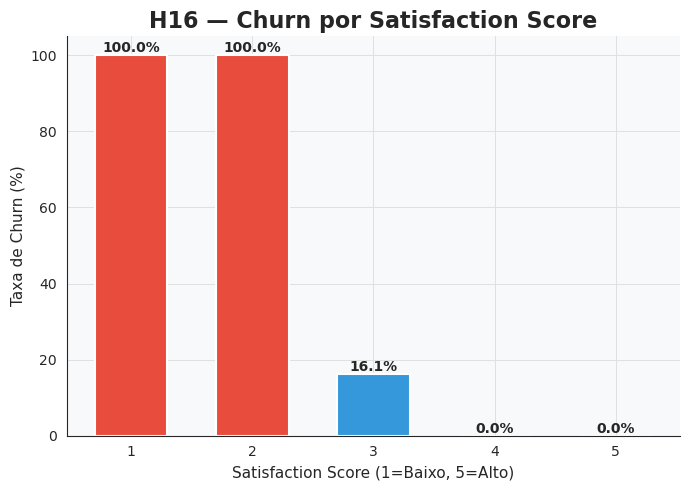

In [20]:
fig = plt.figure(figsize=(7,5))
plt.title('H16 — Churn por Satisfaction Score', fontsize=16, fontweight='bold')

cr = churn_rate(df, 'Satisfaction Score')

bars = plt.bar(
    cr['Satisfaction Score'],
    cr['Churn Rate (%)'],
    color=[CHURN_COLOR if v > 40 else NEUTRAL_COLOR for v in cr['Churn Rate (%)']],
    edgecolor='white',
    linewidth=1.5,
    width=0.6
)

plt.xlabel('Satisfaction Score (1=Baixo, 5=Alto)')
plt.ylabel('Taxa de Churn (%)')

for bar, val in zip(bars, cr['Churn Rate (%)']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{val:.1f}%',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

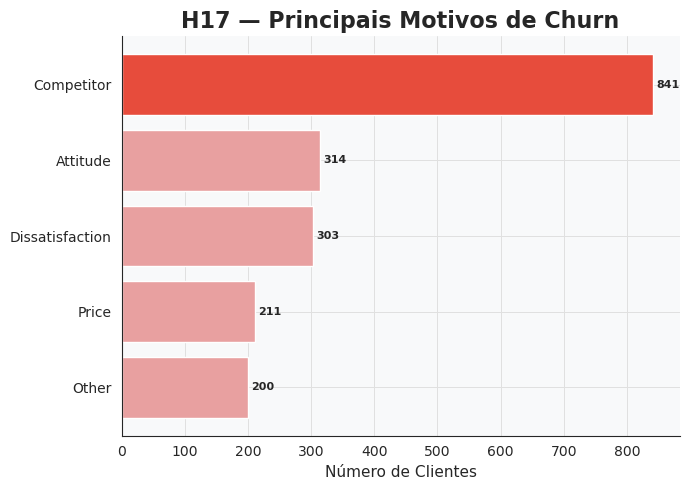

In [21]:
fig = plt.figure(figsize=(7,5))
plt.title('H17 — Principais Motivos de Churn', fontsize=16, fontweight='bold')

cat = df[df['Churn Label'] == 'Yes']['Churn Category'].value_counts()

colors_cat = [CHURN_COLOR if i == 0 else '#E8A0A0' for i in range(len(cat))]

bars = plt.barh(
    cat.index[::-1],
    cat.values[::-1],
    color=colors_cat[::-1],
    edgecolor='white',
    linewidth=1.0
)

plt.xlabel('Número de Clientes')

for bar, val in zip(bars, cat.values[::-1]):
    plt.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height()/2,
        str(val),
        va='center',
        fontsize=8,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

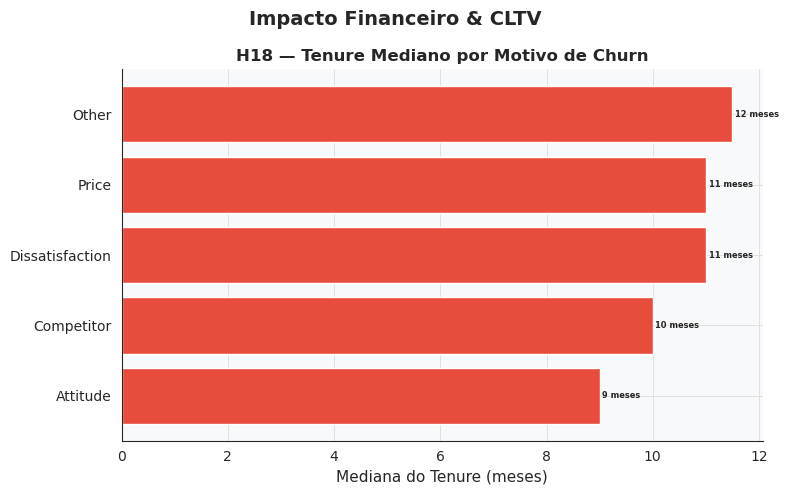

In [22]:
fig = plt.figure(figsize=(8,5))

plt.suptitle('Impacto Financeiro & CLTV', fontsize=14, fontweight='bold')
plt.title('H18 — Tenure Mediano por Motivo de Churn', fontsize=12)

tenure_reason = (
    df[df['Churn Label']=='Yes']
    .groupby('Churn Category')['Tenure in Months']
    .median()
    .sort_values()
)

colors_tr = [
    CHURN_COLOR if v < 20 else '#E8A0A0'
    for v in tenure_reason.values
]

bars = plt.barh(
    tenure_reason.index,
    tenure_reason.values,
    color=colors_tr,
    edgecolor='white'
)

plt.xlabel('Mediana do Tenure (meses)')

for bar, val in zip(bars, tenure_reason.values):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{val:.0f} meses',
        va='center',
        fontsize=6,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

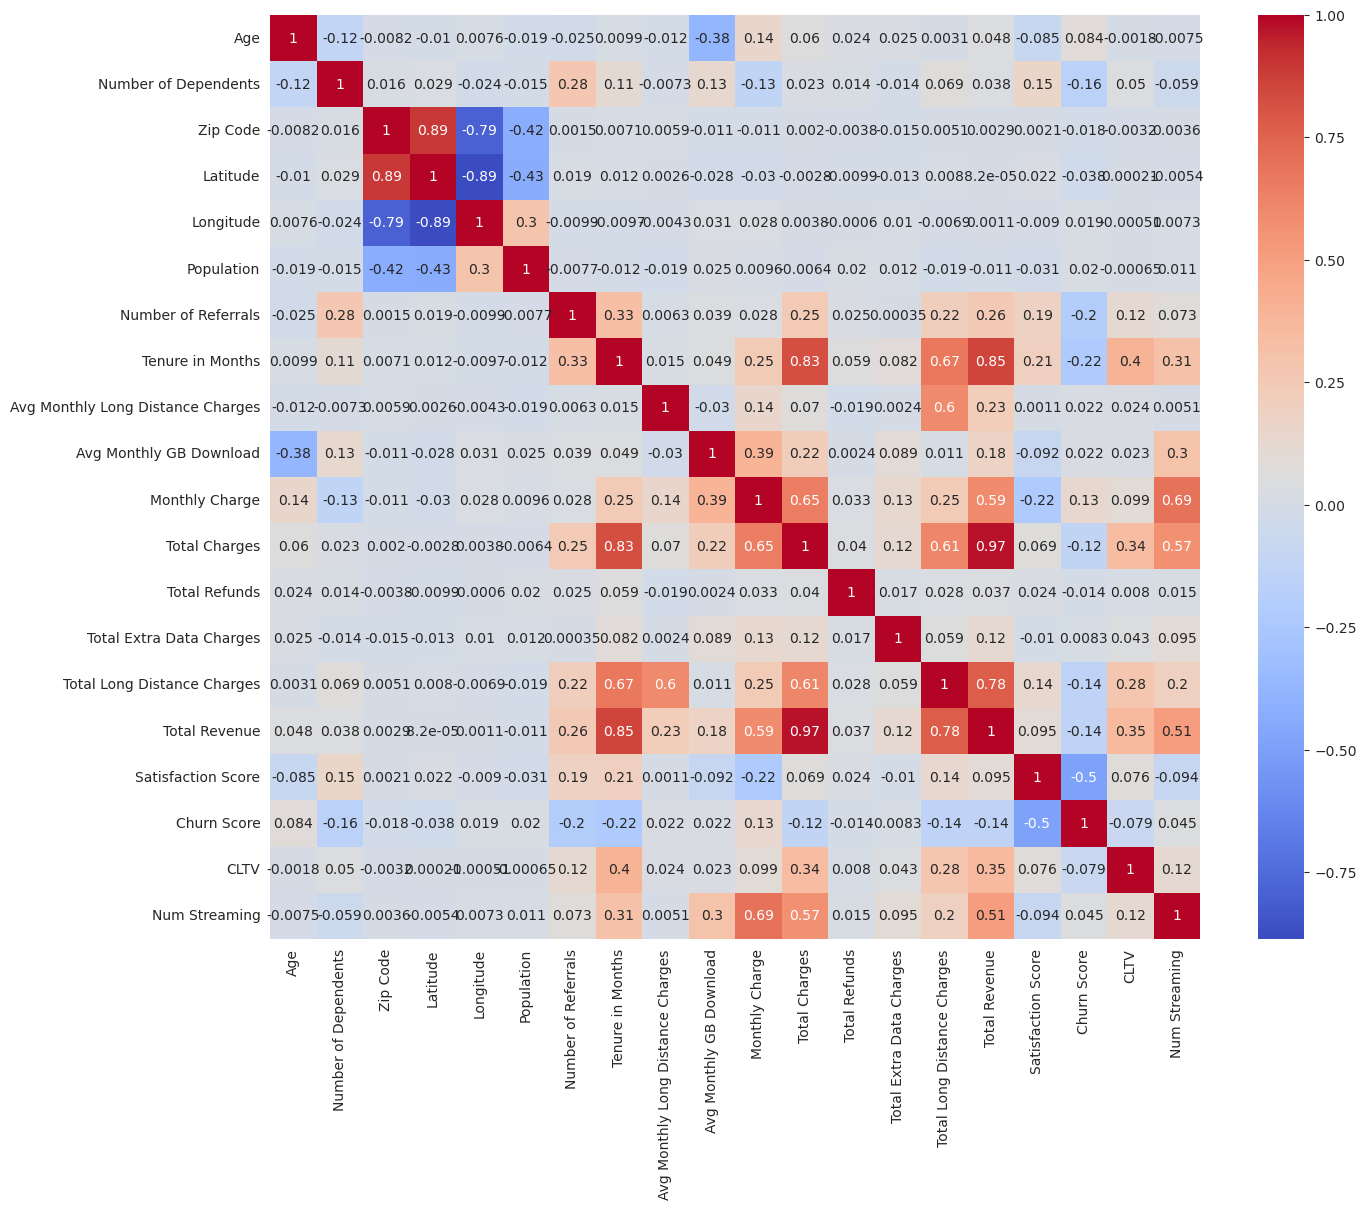

In [23]:
fig = plt.figure(figsize=(15,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm");

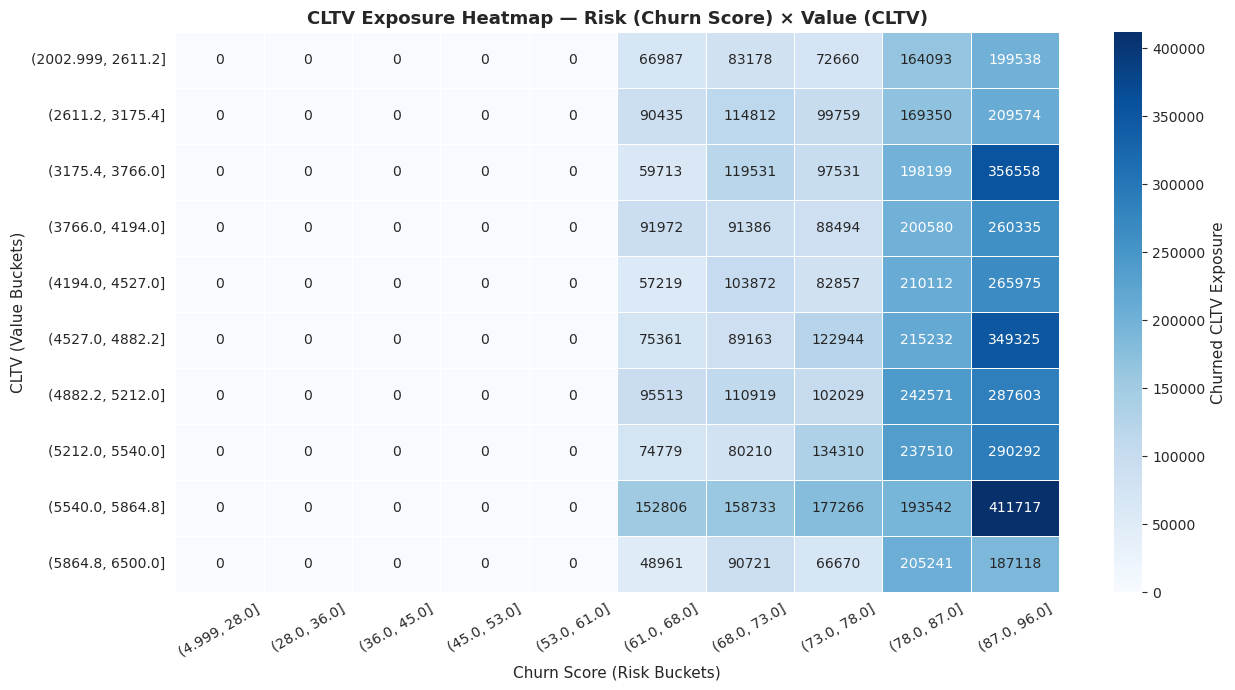

In [24]:
CHURN_COL = "Churn Label"
SCORE_COL = "Churn Score"
CLTV_COL = "CLTV"

# converter churn para 0/1
df[CHURN_COL] = df[CHURN_COL].map({"Yes": 1, "No": 0})

# -------------------------------------------------------
# criar buckets
# -------------------------------------------------------

df["score_bin"] = pd.qcut(df[SCORE_COL], 10, duplicates="drop")
df["cltv_bin"] = pd.qcut(df[CLTV_COL], 10, duplicates="drop")

# -------------------------------------------------------
# calcular métricas
# -------------------------------------------------------

cell = (
    df
    .groupby(["cltv_bin", "score_bin"])
    .agg(
        customers=(CHURN_COL, "size"),
        churn_rate=(CHURN_COL, "mean"),
        churned_cltv_exposure=(CLTV_COL, lambda x: x[df.loc[x.index, CHURN_COL] == 1].sum())
    )
    .reset_index()
)

# -------------------------------------------------------
# matriz do heatmap
# -------------------------------------------------------

heatmap_matrix = cell.pivot(
    index="cltv_bin",
    columns="score_bin",
    values="churned_cltv_exposure"
).fillna(0)

# -------------------------------------------------------
# plot
# -------------------------------------------------------

plt.figure(figsize=(13,7))

sns.heatmap(
    heatmap_matrix,
    cmap="Blues",
    linewidths=0.5,
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Churned CLTV Exposure"}
)

plt.title("CLTV Exposure Heatmap — Risk (Churn Score) × Value (CLTV)")
plt.xlabel("Churn Score (Risk Buckets)")
plt.ylabel("CLTV (Value Buckets)")

plt.xticks(rotation=30)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

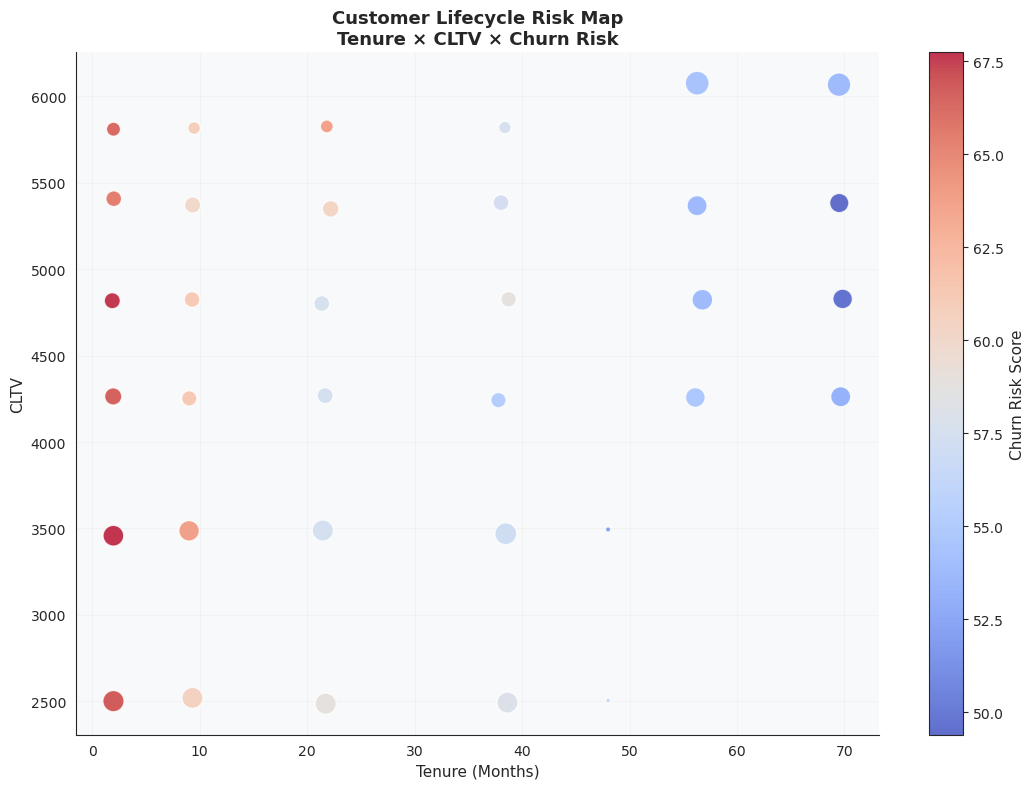

In [25]:
TENURE_COL = "Tenure in Months"
#CLTV_COL = "CLTV"
#SCORE_COL = "Churn Score"
#CHURN_COL = "Churn Label"

# converter churn
#df[CHURN_COL] = df[CHURN_COL].map({"Yes":1, "No":0})

# garantir tipos numéricos
df[TENURE_COL] = pd.to_numeric(df[TENURE_COL], errors="coerce")
df[CLTV_COL] = pd.to_numeric(df[CLTV_COL], errors="coerce")
df[SCORE_COL] = pd.to_numeric(df[SCORE_COL], errors="coerce")

df = df.dropna(subset=[TENURE_COL,CLTV_COL,SCORE_COL])

# -----------------------
# criar segmentos
# -----------------------

df["tenure_band"] = pd.qcut(df[TENURE_COL], 6, duplicates="drop")
df["cltv_band"] = pd.qcut(df[CLTV_COL], 6, duplicates="drop")

seg = (
    df
    .groupby(["tenure_band","cltv_band"])
    .agg(
        customers=(CHURN_COL,"size"),
        churn_rate=(CHURN_COL,"mean"),
        avg_score=(SCORE_COL,"mean"),
        avg_cltv=(CLTV_COL,"mean"),
        avg_tenure=(TENURE_COL,"mean")
    )
    .reset_index()
)

# -----------------------
# plot
# -----------------------

plt.figure(figsize=(11,8))

scatter = plt.scatter(
    seg["avg_tenure"],
    seg["avg_cltv"],
    s=seg["customers"]*0.8,
    c=seg["avg_score"],
    cmap="coolwarm",
    alpha=0.8,
    edgecolor="white",
    linewidth=1
)

plt.colorbar(scatter,label="Churn Risk Score")

plt.xlabel("Tenure (Months)")
plt.ylabel("CLTV")

plt.title("Customer Lifecycle Risk Map\nTenure × CLTV × Churn Risk")

plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

| Região                           | Significado               |
| -------------------------------- | ------------------------- |
| **alto CLTV + alto churn score** | 🚨 maior risco financeiro |
| alto CLTV + baixo risco          | clientes fiéis            |
| baixo CLTV + alto risco          | churn esperado            |
| baixo CLTV + baixo risco         | clientes estáveis         |

### 📉 Churn concentrado no início do ciclo de vida do cliente

Isso normalmente aponta para problemas de:

**- onboarding**

**- expectativa vs produto**

**- pricing**

**- experiência inicial**

Empresas SaaS chamam isso de **"Early Lifecycle Churn".**


In [26]:
#calcular Revenue at Risk esperado
df["revenue_at_risk"] = df["CLTV"] * (df["Churn Score"]/100)

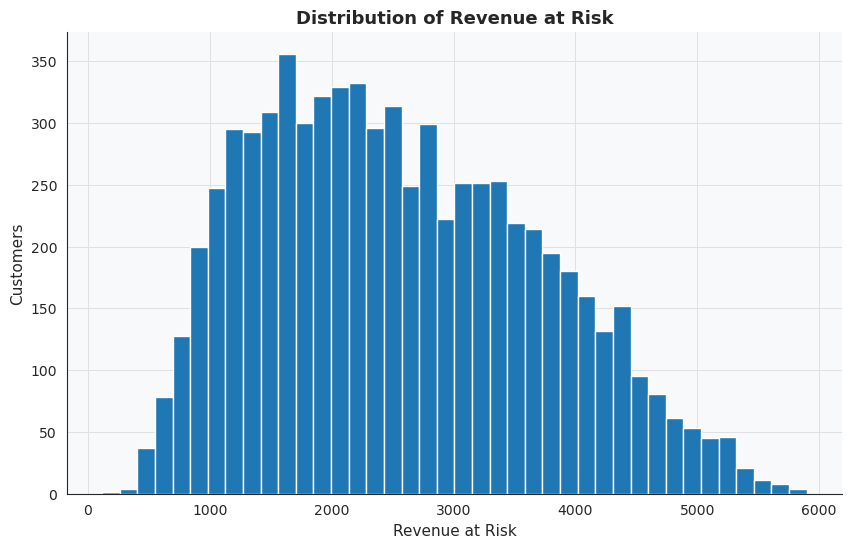

In [27]:
plt.figure(figsize=(10,6))

plt.hist(df["revenue_at_risk"], bins=40)

plt.xlabel("Revenue at Risk")
plt.ylabel("Customers")

plt.title("Distribution of Revenue at Risk")

plt.show()

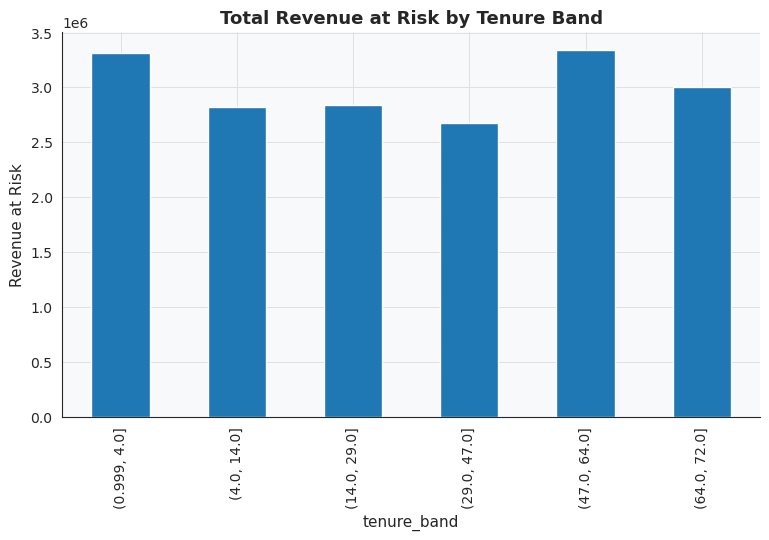

In [28]:
risk = df.groupby("tenure_band")["revenue_at_risk"].sum()

risk.plot(kind="bar", figsize=(9,5))

plt.title("Total Revenue at Risk by Tenure Band")
plt.ylabel("Revenue at Risk")

plt.show()

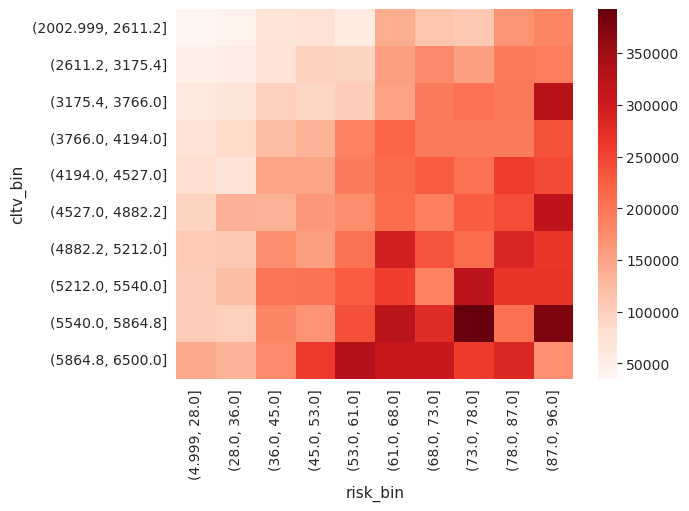

In [29]:
df["risk_bin"] = pd.qcut(df["Churn Score"],10)
df["cltv_bin"] = pd.qcut(df["CLTV"],10)

mat = df.pivot_table(
    values="revenue_at_risk",
    index="cltv_bin",
    columns="risk_bin",
    aggfunc="sum"
)

sns.heatmap(mat, cmap="Reds");

### 1️⃣ Clientes de baixo CLTV

Parte superior esquerda do gráfico.

* CLTV baixo

* churn score médio/alto

* Eles churnam mais, mas o impacto financeiro é pequeno.

Ou seja:

* **churn alto, impacto baixo**


### 2️⃣ Clientes de alto CLTV

Parte inferior direita do gráfico.

* CLTV alto

* churn score médio/alto

* Aqui está o problema real.

* **poucos clientes podem representar grande perda financeira**

## Conclusão:
O churn se divide em dois problemas:

**Early churn** :Clientes novos com baixo CLTV.

→ problema de onboarding

**High value churn** Clientes valiosos com risco médio.

→ problema de retenção estratégica

In [30]:
df["revenue_at_risk"].sum()

np.float64(17991721.03)

In [31]:
df["revenue_at_risk"].sum() / df["CLTV"].sum()

np.float64(0.5805413422219403)

Mais da **metade do valor potencial da base de clientes** tem alguma probabilidade relevante de churn.

Mas cuidado: **isso não** significa que 58% da receita vai desaparecer.
Significa que **58% da receita ponderada pela probabilidade** de churn está exposta ao risco.

In [32]:
df["risk_tier"] = pd.qcut(df["revenue_at_risk"],4,
labels=["Low","Medium","High","Critical"])

In [33]:
df.groupby("risk_tier")["CLTV"].sum()

risk_tier
Low         6573818
Medium      7055973
High        7993589
Critical    9367903
Name: CLTV, dtype: int64

| Tier     | CLTV total |
| -------- | ---------- |
| Low      | 6.57M      |
| Medium   | 7.05M      |
| High     | 7.99M      |
| Critical | **9.36M**  |


In [34]:
df.groupby("risk_tier").size()

risk_tier
Low         1761
Medium      1761
High        1760
Critical    1761
dtype: int64

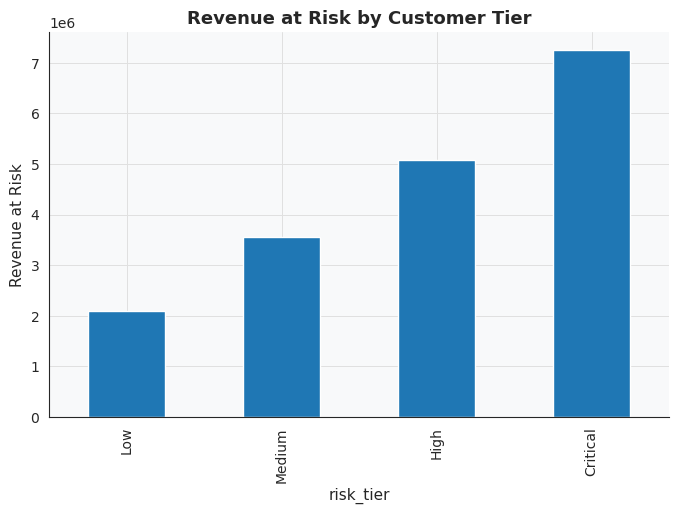

In [35]:
risk = df.groupby("risk_tier")["revenue_at_risk"].sum()

risk.plot(kind="bar", figsize=(8,5))

plt.title("Revenue at Risk by Customer Tier")
plt.ylabel("Revenue at Risk")

plt.show()

Aproximadamente **U$18M em valor de clientes está exposto ao risco de churn**, representando **58% da receita potencial da base.**
A maior concentração desse risco está no segmento Critical, que também representa o maior volume de CLTV.

In [36]:
#Quais clientes precisam de intervenção imediata
df.sort_values("revenue_at_risk", ascending=False)[
["Customer ID","CLTV","Churn Score","revenue_at_risk"]
].head(10)

,Customer ID,CLTV,Churn Score,revenue_at_risk
1450,2886-KEFUM,6144,96,5898.24
2239,2225-ZRGSG,6173,95,5864.35
1512,4143-HHPMK,6402,91,5825.82
1532,0565-IYCGT,6230,93,5793.90
1902,5089-IFSDP,6424,89,5717.36
38,4913-EHYUI,6268,91,5703.88
2152,8199-ZLLSA,6255,91,5692.05
1454,0637-YLETY,5915,96,5678.40
77,5565-FILXA,5913,96,5676.48
1890,1725-IQNIY,6274,90,5646.60


In [37]:
df.sort_values("revenue_at_risk", ascending=False).head(20)

top_10_pct = df.nlargest(int(len(df)*0.1), "revenue_at_risk")

top_10_pct["revenue_at_risk"].sum() / df["revenue_at_risk"].sum()

np.float64(0.18234993498006677)

## Existem duas implicações importantes.

### 1️⃣ Não existe um pequeno grupo crítico

- Não conseguimos resolver o problema atacando só alguns clientes grandes.

- Isso significa que ações individuais de retenção podem ter baixo impacto.


### 2️⃣ O churn parece ser um problema estrutural

- Quando o risco está espalhado, normalmente significa:

- *experiência do produto

- *preço

- *suporte

- *valor percebido

Ou seja, algo no **produto** ou **modelo de negócio**.

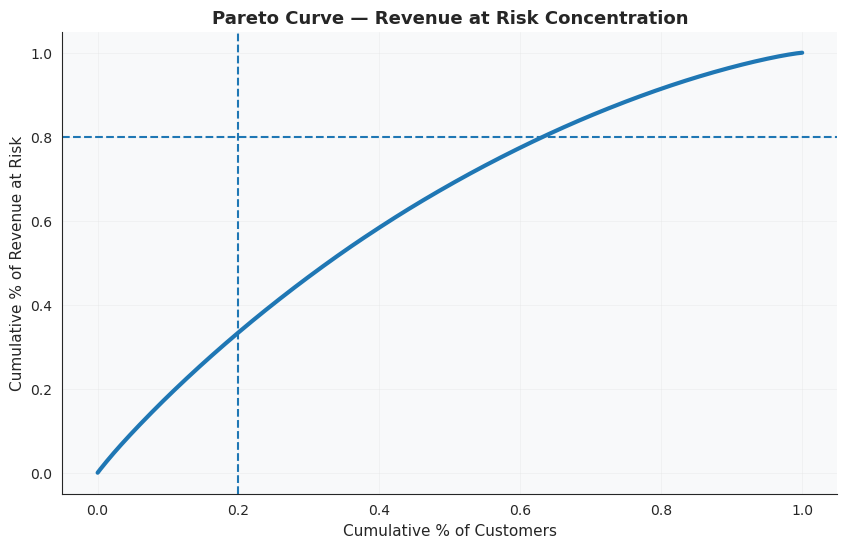

In [38]:
# ordenar clientes por risco
pareto = df.sort_values("revenue_at_risk", ascending=False)

# calcular acumulado
pareto["cum_risk"] = pareto["revenue_at_risk"].cumsum()
pareto["cum_risk_pct"] = pareto["cum_risk"] / pareto["revenue_at_risk"].sum()

pareto["cum_customers"] = np.arange(1, len(pareto)+1)
pareto["cum_customers_pct"] = pareto["cum_customers"] / len(pareto)

# -------------------
# plot
# -------------------

fig, ax = plt.subplots(figsize=(10,6))

ax.plot(
    pareto["cum_customers_pct"],
    pareto["cum_risk_pct"],
    linewidth=3
)

ax.axhline(0.8, linestyle="--")
ax.axvline(0.2, linestyle="--")

ax.set_xlabel("Cumulative % of Customers")
ax.set_ylabel("Cumulative % of Revenue at Risk")

ax.set_title("Pareto Curve — Revenue at Risk Concentration")

ax.grid(alpha=0.3)

plt.show()

In [40]:
#Churn por tenure
df.groupby("tenure_band")["Churn Label"].mean() * 100

tenure_band
(0.999, 4.0]    55.419723
(4.0, 14.0]     36.625874
(14.0, 29.0]    25.876461
(29.0, 47.0]    20.324509
(47.0, 64.0]    12.562814
(64.0, 72.0]     6.492335
Name: Churn Label, dtype: float64

In [48]:
df.groupby("Internet Type")["Churn Label"].mean() * 100

Internet Type
Cable          25.662651
DSL            18.583535
Fiber Optic    40.724876
Name: Churn Label, dtype: float64

In [49]:
df.groupby("Contract")["Churn Label"].mean() * 100

Contract
Month-to-Month    45.844875
One Year          10.709677
Two Year           2.549124
Name: Churn Label, dtype: float64

In [42]:
risk_segment = df.groupby("Contract")["revenue_at_risk"].sum()

risk_segment.sort_values(ascending=False)

Contract
Month-to-Month    9631247.72
Two Year          4635049.14
One Year          3725424.17
Name: revenue_at_risk, dtype: float64

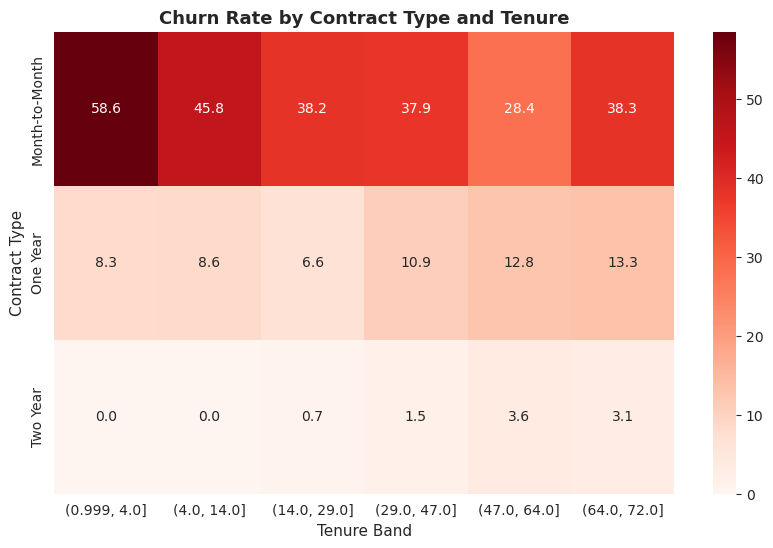

In [47]:
plt.figure(figsize=(10,6))

sns.heatmap(
    pd.crosstab(
        df["Contract"],
        df["tenure_band"],
        values=df["Churn Label"],
        aggfunc="mean"
    )*100,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Churn Rate by Contract Type and Tenure")
plt.ylabel("Contract Type")
plt.xlabel("Tenure Band")

plt.show()

## Análise Geoespaciais

In [51]:
df = pd.read_csv('~/Projeto/Portfolio/Portfolio2/Churn/data/telco.csv')

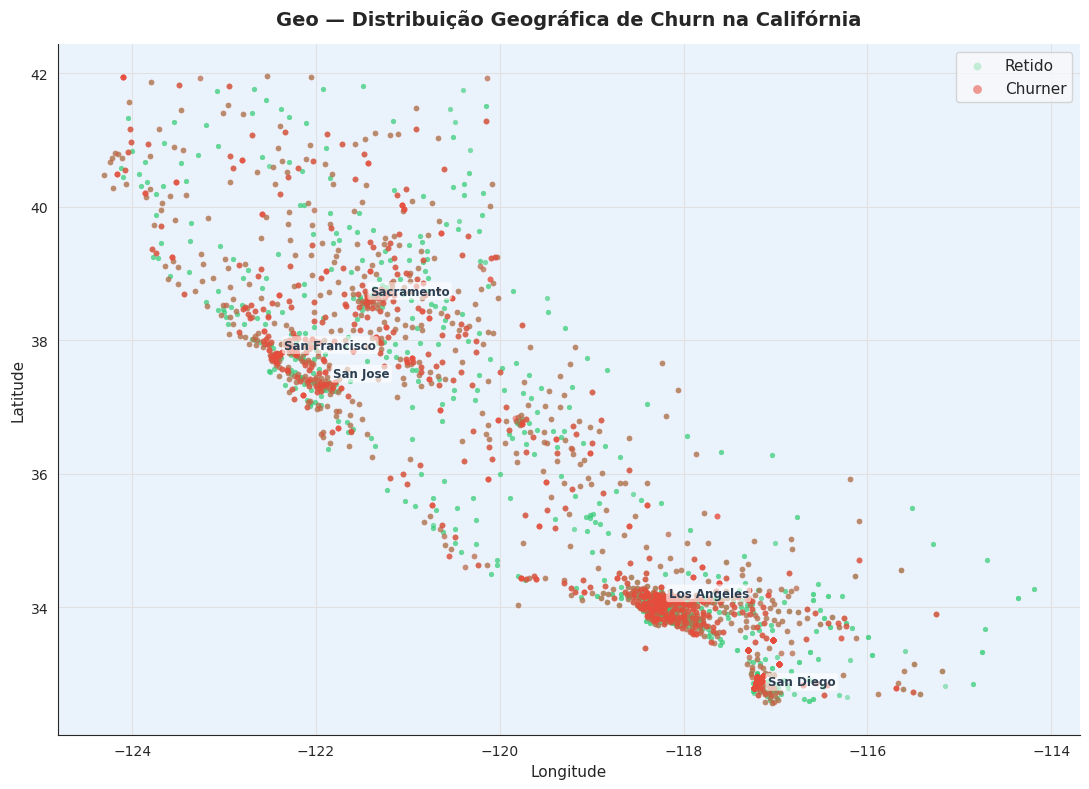

In [52]:
import numpy as np

df['Churn Bin'] = (df['Churn Label'] == 'Yes').astype(int)  # 1 = churner

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#EAF2FB')

retained = df[df['Churn Label'] == 'No']
churned  = df[df['Churn Label'] == 'Yes']

ax.scatter(retained['Longitude'], retained['Latitude'],
           c=RETAIN_COLOR, alpha=0.25, s=14, label='Retido', linewidths=0)
ax.scatter(churned['Longitude'], churned['Latitude'],
           c=CHURN_COLOR, alpha=0.55, s=18, label='Churner', linewidths=0)

ax.set_title('Geo — Distribuição Geográfica de Churn na Califórnia', fontsize=14, pad=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(fontsize=11, markerscale=1.5)

# Anotações das principais cidades
cities_annot = {
    'Los Angeles'  : (-118.24, 34.05),
    'San Diego'    : (-117.16, 32.72),
    'San Jose'     : (-121.89, 37.34),
    'San Francisco': (-122.42, 37.77),
    'Sacramento'   : (-121.49, 38.58),
}
for city, (lon, lat) in cities_annot.items():
    ax.annotate(city, (lon, lat), fontsize=8.5, color='#2C3E50', fontweight='bold',
                xytext=(5, 5), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

plt.tight_layout()
plt.show()


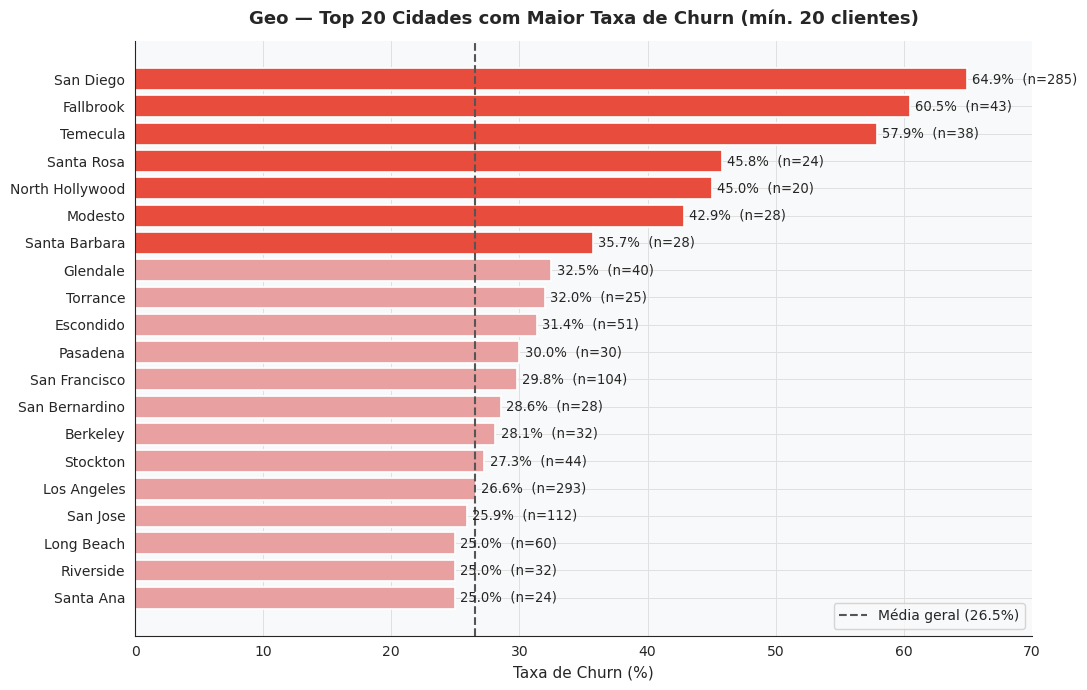

In [53]:
city_stats = (
    df.groupby('City')
      .agg(total=('Churn Label', 'count'), churned=('Churn Bin', 'sum'))
      .reset_index()
)
city_stats['churn_rate'] = city_stats['churned'] / city_stats['total'] * 100

# Filtra cidades com ao menos 20 clientes (estatisticamente relevantes)
top20 = (city_stats[city_stats['total'] >= 20]
         .sort_values('churn_rate', ascending=False)
         .head(20))

fig, ax = plt.subplots(figsize=(11, 7))
colors_bar = [CHURN_COLOR if r > 35 else '#E8A0A0' for r in top20['churn_rate']]

bars = ax.barh(top20['City'][::-1], top20['churn_rate'][::-1],
               color=colors_bar[::-1], edgecolor='white', linewidth=1.2)

for bar, val, n in zip(bars, top20['churn_rate'][::-1], top20['total'][::-1]):
    ax.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%  (n={n})', va='center', fontsize=9.5)

ax.axvline(df['Churn Bin'].mean() * 100, color='#555', linestyle='--',
           linewidth=1.5, label=f'Média geral ({df["Churn Bin"].mean()*100:.1f}%)')

ax.set_title('Geo — Top 20 Cidades com Maior Taxa de Churn (mín. 20 clientes)', fontsize=13, pad=12)
ax.set_xlabel('Taxa de Churn (%)')
ax.set_xlim(0, 70)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

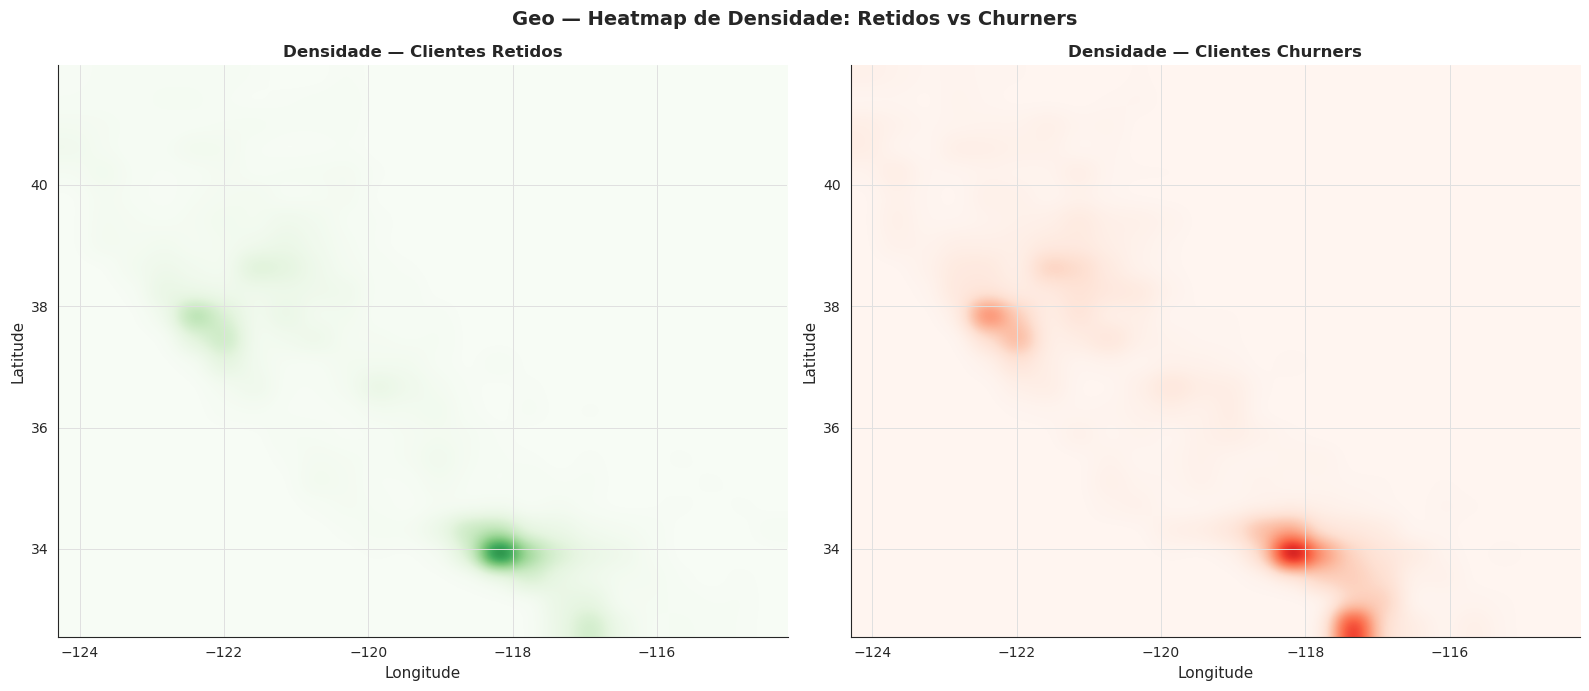

In [54]:
lat_bins = np.linspace(df['Latitude'].min(),  df['Latitude'].max(),  25)
lon_bins = np.linspace(df['Longitude'].min(), df['Longitude'].max(), 25)

def make_density_heatmap(data, ax, title, cmap):
    h, xedges, yedges = np.histogram2d(
        data['Longitude'], data['Latitude'],
        bins=[lon_bins, lat_bins]
    )
    ax.imshow(h.T, origin='lower', aspect='auto',
              extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
              cmap=cmap, interpolation='gaussian')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

make_density_heatmap(df[df['Churn Label'] == 'No'],  axes[0],
                     'Densidade — Clientes Retidos',  'Greens')
make_density_heatmap(df[df['Churn Label'] == 'Yes'], axes[1],
                     'Densidade — Clientes Churners', 'Reds')

fig.suptitle('Geo — Heatmap de Densidade: Retidos vs Churners',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


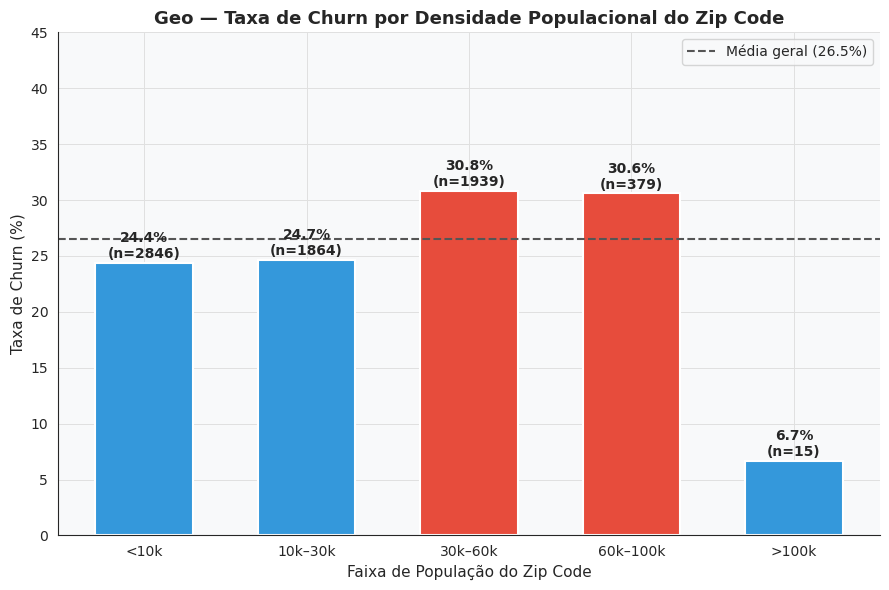

In [55]:
pop_labels = ['<10k', '10k–30k', '30k–60k', '60k–100k', '>100k']

df['Pop Faixa'] = pd.cut(
    df['Population'],
    bins=[0, 10_000, 30_000, 60_000, 100_000, df['Population'].max() + 1],
    labels=pop_labels
)

pop_churn = (
    df.groupby('Pop Faixa', observed=True)
      .agg(total=('Churn Bin', 'count'), churned=('Churn Bin', 'sum'))
      .assign(churn_rate=lambda x: x['churned'] / x['total'] * 100)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))
colors_pop = [CHURN_COLOR if r > 28 else NEUTRAL_COLOR for r in pop_churn['churn_rate']]

bars2 = ax.bar(pop_churn['Pop Faixa'], pop_churn['churn_rate'],
               color=colors_pop, edgecolor='white', linewidth=1.5, width=0.6)

for bar, val, tot in zip(bars2, pop_churn['churn_rate'], pop_churn['total']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
            f'{val:.1f}%\n(n={tot})', ha='center', fontsize=10, fontweight='bold')

ax.axhline(df['Churn Bin'].mean() * 100, color='#555', linestyle='--',
           linewidth=1.5, label=f'Média geral ({df["Churn Bin"].mean()*100:.1f}%)')

ax.set_title('Geo — Taxa de Churn por Densidade Populacional do Zip Code', fontsize=13)
ax.set_xlabel('Faixa de População do Zip Code')
ax.set_ylabel('Taxa de Churn (%)')
ax.set_ylim(0, 45)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


### 📌 Conclusões — Análise Geoespacial

| Análise | Achado |
|---|---|
| **Scatter Map** | Churners concentrados nas regiões metropolitanas densas (LA, SD, SF) |
| **Top Cidades** | Cidades menores com amostras limitadas podem ter taxas infladas; grandes cidades ficam próximas da média |
| **Heatmap** | Distribuição espacial de retidos e churners é muito similar — localização per se não é fator isolado de churn |
| **Pop. Faixa** | Zip codes de população média (10k–60k) apresentam churn ligeiramente acima da média; regiões muito densas (>100k) ficam na média |

**✅ Hipótese H19 — Resultado:** A localização geográfica **não é um preditor forte** de churn de forma isolada.
O padrão espacial reflete a distribuição geral da base de clientes.
Variáveis como **tipo de contrato, satisfação e tipo de internet** são muito mais determinantes.

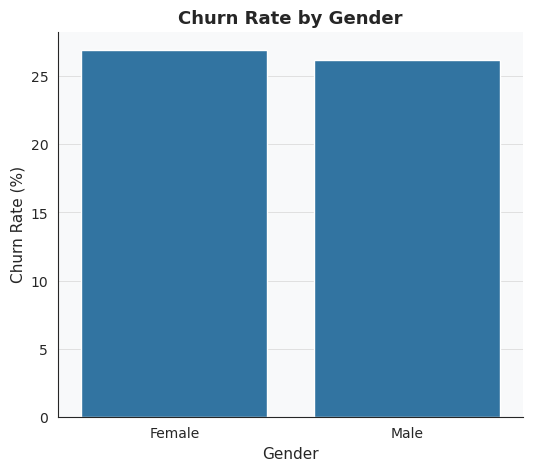

In [60]:
df["Churn Binary"] = df["Churn Label"].map({"Yes":1, "No":0})

plt.figure(figsize=(6,5))

churn_gender = df.groupby("Gender")["Churn Binary"].mean()*100

sns.barplot(x=churn_gender.index, y=churn_gender.values)

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Gender")

plt.show()

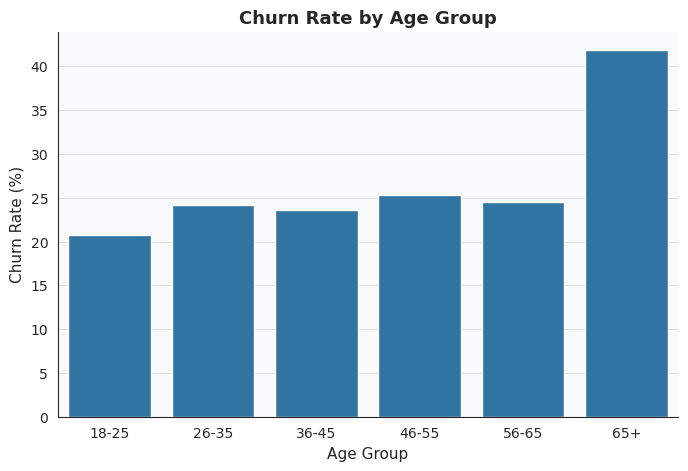

In [61]:
df["age_band"] = pd.cut(
    df["Age"],
    bins=[18,25,35,45,55,65,80],
    labels=["18-25","26-35","36-45","46-55","56-65","65+"]
)

plt.figure(figsize=(8,5))

churn_age = df.groupby("age_band")["Churn Binary"].mean()*100

sns.barplot(x=churn_age.index, y=churn_age.values)

plt.title("Churn Rate by Age Group")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Age Group")

plt.show()

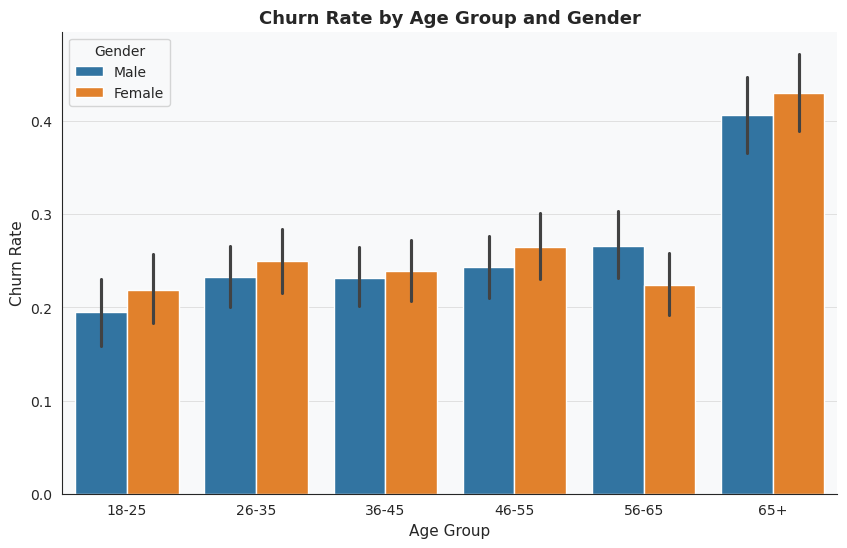

In [62]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="age_band",
    y="Churn Binary",
    hue="Gender"
)

plt.title("Churn Rate by Age Group and Gender")
plt.ylabel("Churn Rate")
plt.xlabel("Age Group")

plt.show()

Com exceção da faixa de 56-65 anos aonde os homens cancelaram mais os produtos, o restante das faixas etárias as mulheres tendem a cancelar mais os serviços. 